# Data Analysis of Online Retail II
Data analysis on the Online Retail II dataset to understand customer behavior and sales patterns.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Loading the dataset
file_path = '/content/online_retail_II.xlsx'
# Note: This file contains multiple sheets usually for different years.
# Loading the first sheet for initial analysis.
df = pd.read_excel(file_path)

# Display basic information
print("Dataset Shape:", df.shape)
display(df.info())
display(df.head())

Dataset Shape: (525461, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


None

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Data Quality Audit
Identifying missing values and duplicate rows in the dataset.

In [ ]:
# Identify missing values
missing_values = df.isnull().sum()
print("Missing Values per Column:")
print(missing_values[missing_values > 0])

# Identify duplicate rows
duplicates = df.duplicated().sum()
print(f"\nTotal Duplicate Rows: {duplicates}")

Missing Values per Column:
Description      2928
Customer ID    107927
dtype: int64

Total Duplicate Rows: 6865


## Sales Analysis: Top Products
Calculating revenue and identifying the top 10 best-selling products.

In [ ]:
# Calculate Revenue
df['Revenue'] = df['Quantity'] * df['Price']

# Top 10 by Quantity
top_qty = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

# Top 10 by Revenue
top_rev = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

print("Top 10 Products by Quantity:")
display(top_qty)

print("\nTop 10 Products by Revenue:")
display(top_rev)

Top 10 Products by Quantity:


,Quantity
Description,
WHITE HANGING HEART T-LIGHT HOLDER,57733
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54698
BROCADE RING PURSE,47647
PACK OF 72 RETRO SPOT CAKE CASES,46106
ASSORTED COLOUR BIRD ORNAMENT,44925
60 TEATIME FAIRY CAKE CASES,36326
PACK OF 60 PINK PAISLEY CAKE CASES,31822
JUMBO BAG RED RETROSPOT,30727
SMALL POPCORN HOLDER,29500



Top 10 Products by Revenue:


,Revenue
Description,
REGENCY CAKESTAND 3 TIER,163051.46
WHITE HANGING HEART T-LIGHT HOLDER,157865.43
DOTCOM POSTAGE,116401.99
ASSORTED COLOUR BIRD ORNAMENT,72454.12
PAPER CHAIN KIT 50'S CHRISTMAS,57870.20
JUMBO BAG RED RETROSPOT,56444.61
PARTY BUNTING,49645.52
ROTATING SILVER ANGELS T-LIGHT HLDR,47672.49
POSTAGE,46092.36


## Final Business Insights
Based on the Exploratory Data Analysis, here are 5 key business insights:

1. **High Concentration of Revenue in the UK**: The United Kingdom is the primary market, significantly outperforming other countries. Expansion efforts should focus on mirroring the UK's success in top international markets like EIRE or Germany.
2. **Seasonality and Year-End Peaks**: The monthly revenue trend indicates a significant spike towards the end of the year, likely driven by holiday shopping. Inventory planning should be optimized for Q4.
3. **Data Quality Issues (Missing Customer Data)**: Over 100,000 transactions lack a 'Customer ID'. Improving the registration process or guest-checkout tracking could provide better personalization and retention data.
4. **Significant Outliers in Quantity**: The box plots reveal extreme outliers in both positive and negative quantities. Negative quantities suggest high return rates or cancellations that need further operational investigation.
5. **Top Products Driven by Giftware**: Best-selling items like the 'REGENCY CAKESTAND 3 TIER' and 'WHITE HANGING HEART T-LIGHT HOLDER' indicate that the retailer's core strength lies in decorative home and giftware items.

### Project Q&A (Quick Reference)

**Q1: What is the total size of the dataset?**
**A:** The dataset contains 525,461 transactions and 8 original columns.

**Q2: Are there any data quality issues?**
**A:** Yes. We identified 107,927 missing Customer IDs, 2,928 missing product descriptions, and 6,865 duplicate rows.

**Q3: Which product is the top performer?**
**A:** 'WHITE HANGING HEART T-LIGHT HOLDER' is the best-seller by quantity, while 'REGENCY CAKESTAND 3 TIER' leads in total revenue.

**Q4: Which country is the most important for the business?**
**A:** The United Kingdom, generating over 8 million in revenue—significantly more than all other countries combined.

**Q5: Is there seasonality in the sales?**
**A:** Yes. Revenue shows a clear upward trend starting in September, peaking in November, indicating high holiday season demand.

**Q6: What do the outliers in the data represent?**
**A:** Outliers in 'Quantity' and 'Price' include negative values (likely returns or cancellations) and bulk purchases which deviate significantly from the average transaction.

**Q7: Is there a strong correlation between price and quantity?**
**A:** No. The correlation heatmap shows a near-zero correlation (-0.00), suggesting that higher prices do not strictly result in lower quantities in this specific giftware niche.

## Sales Performance by Country
Analyzing which countries generate the most revenue and orders.

Detailed Country Performance (Top 10):


,Revenue,Quantity,Order_Count
Country,,,
United Kingdom,8194777.533,4429046,26633
EIRE,352242.730,188704,457
Netherlands,263863.410,181823,150
Germany,196290.351,107133,513
France,130769.900,74471,297
Sweden,51213.510,52238,83
Denmark,46972.950,227030,33
Switzerland,43343.410,22053,50
Spain,37084.900,18332,85


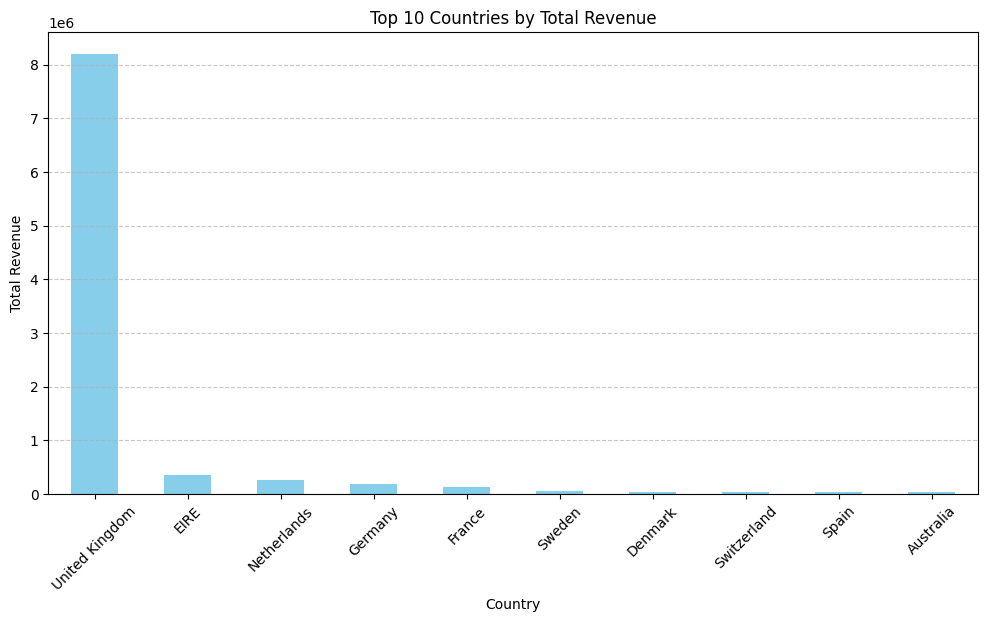

In [ ]:
import matplotlib.pyplot as plt

# Grouping by country for detailed performance analysis
country_performance = df.groupby('Country').agg({
    'Revenue': 'sum',
    'Quantity': 'sum',
    'Invoice': 'nunique'
}).rename(columns={'Invoice': 'Order_Count'}).sort_values(by='Revenue', ascending=False)

print("Detailed Country Performance (Top 10):")
display(country_performance.head(10))

# Visualizing Top 10 Countries by Revenue
plt.figure(figsize=(12, 6))
country_performance.head(10)['Revenue'].plot(kind='bar', color='skyblue')
plt.title('Top 10 Countries by Total Revenue')
plt.ylabel('Total Revenue')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Monthly Revenue Trend
Visualizing how revenue changes over time.

/tmp/ipykernel_974/263982857.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.set_index('InvoiceDate')['Revenue'].resample('M').sum().reset_index()


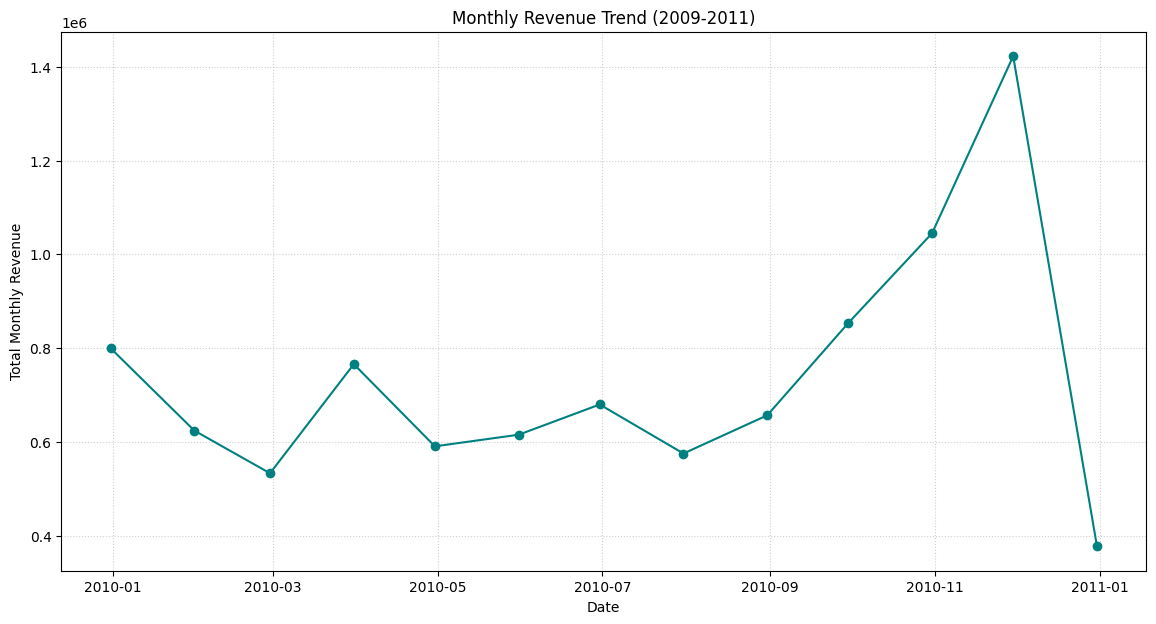

In [ ]:
# Resampling revenue data by month
df_monthly = df.set_index('InvoiceDate')['Revenue'].resample('M').sum().reset_index()

plt.figure(figsize=(14, 7))
plt.plot(df_monthly['InvoiceDate'], df_monthly['Revenue'], marker='o', linestyle='-', color='teal')
plt.title('Monthly Revenue Trend (2009-2011)')
plt.xlabel('Date')
plt.ylabel('Total Monthly Revenue')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## Statistical Analysis: Correlation and Outliers
Creating a correlation heatmap and visualizing outliers in Quantity and Price.

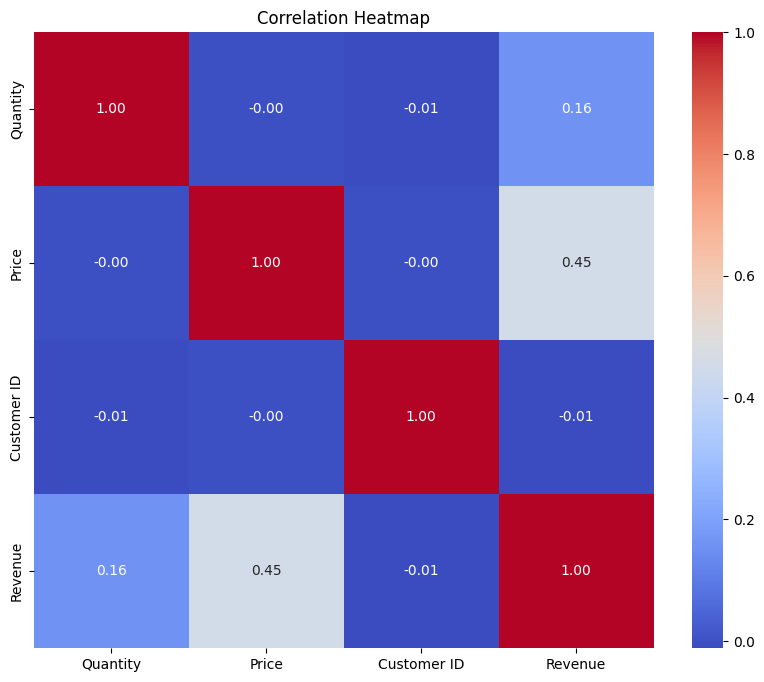

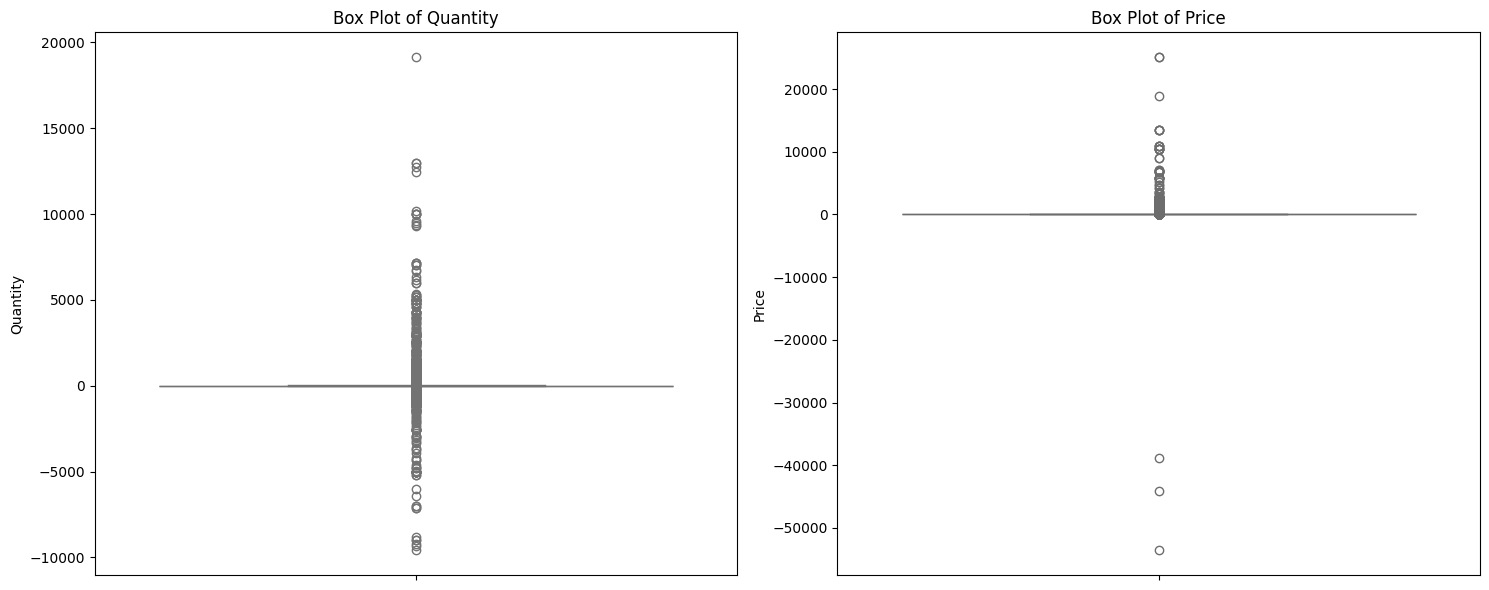

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[['Quantity', 'Price', 'Customer ID', 'Revenue']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Outlier Detection with Box Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df, y='Quantity', ax=axes[0], color='lightgreen')
axes[0].set_title('Box Plot of Quantity')

sns.boxplot(data=df, y='Price', ax=axes[1], color='salmon')
axes[1].set_title('Box Plot of Price')

plt.tight_layout()
plt.show()